In [1]:
# Load necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
#Load the datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
# basic information about the datasets
print(trades.shape)
print(sentiment.shape)

trades.head()

sentiment.head()

trades.info()

sentiment.info()

(211224, 16)
(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dt

In [4]:
# Missing values in the datasets
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [5]:
# Missing values in the datasets
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
# Duplicate values in the datasets
print(trades.duplicated().sum())
print(sentiment.duplicated().sum())

0
0


In [7]:
# Summary statistics of the datasets
trades.describe()
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [8]:
# Convert the dates
trades["Timestamp IST"] = pd.to_datetime( trades["Timestamp IST"],dayfirst=True)

trades["Date"] = trades["Timestamp IST"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date


In [9]:
# Merged the datasets
merged = pd.merge(trades, sentiment[["Date","classification","value"]],
on = "Date", how = "left")

In [10]:
# Rename the columns 
merged.rename(columns = {"classification":"Sentiment","value":"FearGreedScore"}, inplace = True)

In [11]:
merged.head()
merged.shape

(211224, 19)

In [12]:
# Save the clean dataset
merged.to_csv("merged_dataset.csv", index=False)

# Key Metrics Analysis

In [13]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'Sentiment', 'FearGreedScore'],
      dtype='object')

In [14]:
# create a new column to classify trades as profitable or not
merged["Trade_Result"] = np.where(
    merged["Closed PnL"] > 0,
    "Win",
    np.where(
        merged["Closed PnL"] < 0,
        "Loss",
        "Break-even"
    )
)

In [15]:
merged["Trade_Result"].value_counts()

Trade_Result
Break-even    106816
Win            86869
Loss           17539
Name: count, dtype: int64

In [16]:
# Daily Pnl Per Trader
daily_pnl = (
    merged.groupby(["Account", "Date"])["Closed PnL"]
    .sum()
    .reset_index()
)
daily_pnl.rename(columns={"Closed PnL": "Daily_PnL"}, inplace=True)

daily_pnl.head()


,Account,Date,Daily_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [17]:
# win rate per trader
win_rate = (
    merged.groupby("Account")["Trade_Result"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .reset_index(name="Win_Rate")
)

win_rate.head(10)

,Account,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,45.521472
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,32.766787
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,47.590361
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,23.498695
9,0x430f09841d65beb3f27765503d0f850b8bce7713,48.423605


In [18]:
# Average trade size
avg_trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index(name="Avg_Trade_Size")
)

avg_trade_size.head(10)

,Account,Avg_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


In [19]:
# No. of trades per day
daily_trades = (
    merged.groupby("Date")
    .size()
    .reset_index(name="Trades_Per_Day")
)

daily_trades.head(10)

,Date,Trades_Per_Day
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
5,2023-12-17,14
6,2023-12-18,2
7,2023-12-19,15
8,2023-12-20,18
9,2023-12-21,49


In [20]:
# Long vs Short trades
merged["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [21]:
long_short_ratio = (
    merged["Direction"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
)

print(long_short_ratio)

Direction
Open Long                    23.621842
Close Long                   23.045677
Open Short                   18.814623
Close Short                  17.049672
Sell                          9.422225
Buy                           7.913873
Spot Dust Conversion          0.067227
Short > Long                  0.033140
Long > Short                  0.026986
Auto-Deleveraging             0.003787
Liquidated Isolated Short     0.000473
Settlement                    0.000473
Name: Percentage, dtype: float64


In [22]:
# Create a new Direction Group column

merged["Direction_Group"] = merged["Direction"].replace({
    "Open Long": "Long",
    "Close Long": "Long",
    "Open Short": "Short",
    "Close Short": "Short",
    "Buy": "Buy/Sell",
    "Sell": "Buy/Sell",
    "Spot Dust Conversion": "Other",
    "Long > Short": "Other",
    "Short > Long": "Other",
    "Auto-Deleveraging": "Other",
    "Liquidated Isolated Short": "Other",
    "Settlement": "Other"
})

direction_ratio = (
    merged["Direction_Group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(direction_ratio)

Direction_Group
Long        46.67
Short       35.86
Buy/Sell    17.34
Other        0.13
Name: proportion, dtype: float64


# EDA 


In [23]:
# sentiment distribution
merged["Sentiment"].value_counts()

Sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

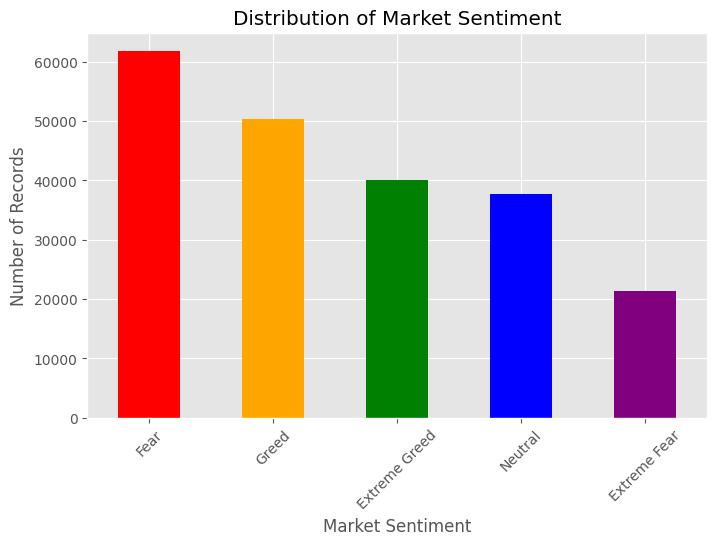

In [24]:
plt.figure(figsize=(8,5))

merged["Sentiment"].value_counts().plot(
    kind="bar",
    color=["red","orange","green","blue","purple"]
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [25]:
pnl_by_sentiment = (
    merged.groupby("Sentiment")["Closed PnL"]
    .mean()
    .sort_values()
)

print(pnl_by_sentiment)

Sentiment
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


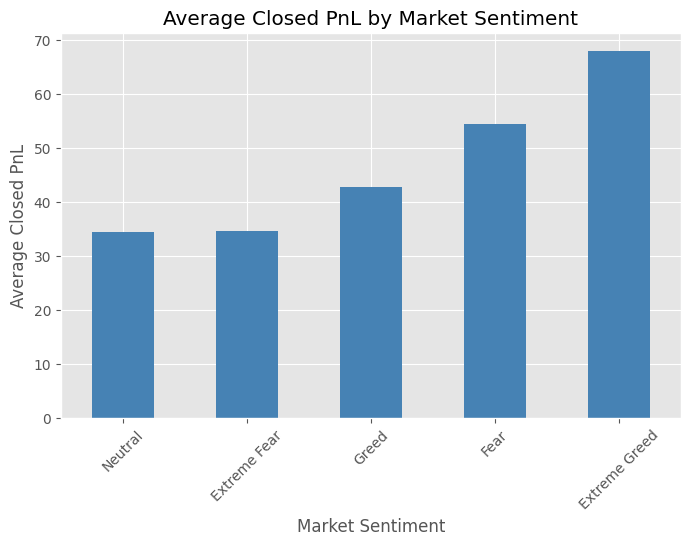

In [26]:
plt.figure(figsize=(8,5))

pnl_by_sentiment.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)

plt.show()

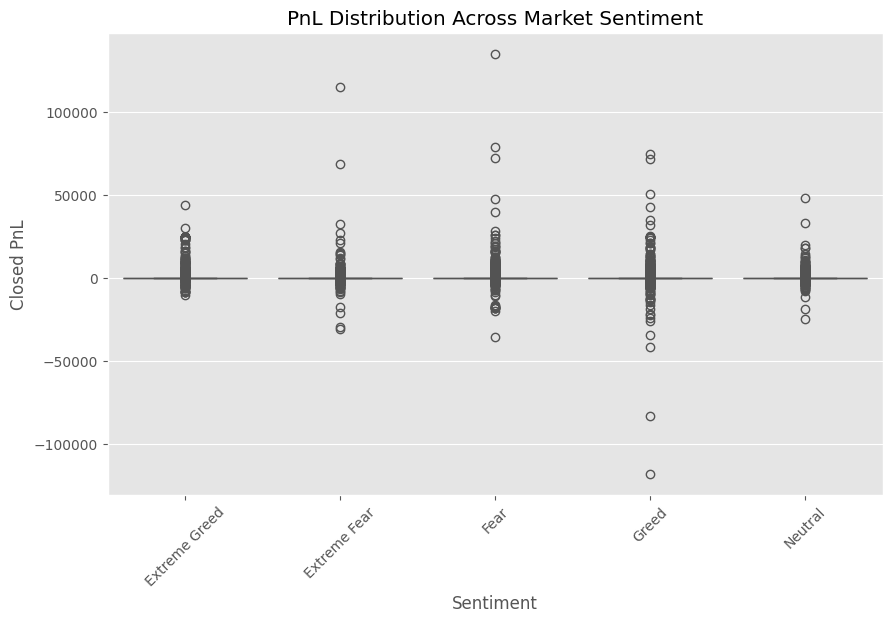

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="Sentiment",
    y="Closed PnL"
)

plt.xticks(rotation=45)

plt.title("PnL Distribution Across Market Sentiment")

plt.show()

In [28]:
win_rate_sentiment = (
    merged.groupby("Sentiment")["Trade_Result"]
    .apply(lambda x: (x=="Win").mean()*100)
)

print(win_rate_sentiment)

Sentiment
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Trade_Result, dtype: float64


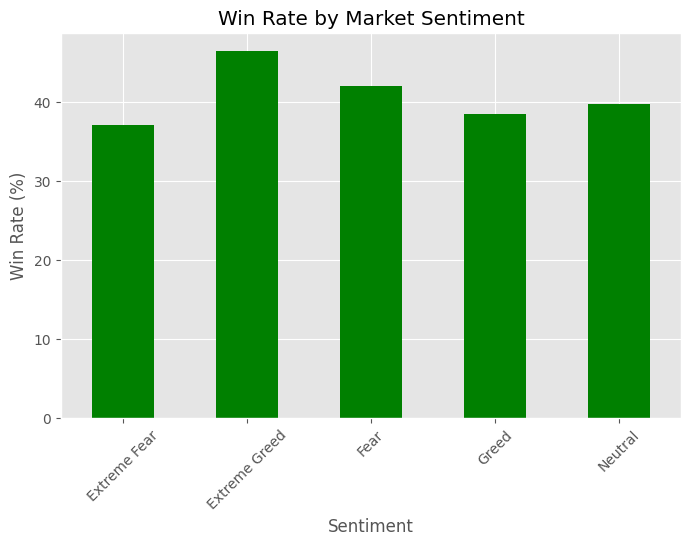

In [29]:
plt.figure(figsize=(8,5))

win_rate_sentiment.plot(
    kind="bar",
    color="green"
)

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [30]:
trade_frequency = (
    merged.groupby("Sentiment")
    .size()
)

print(trade_frequency)

Sentiment
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


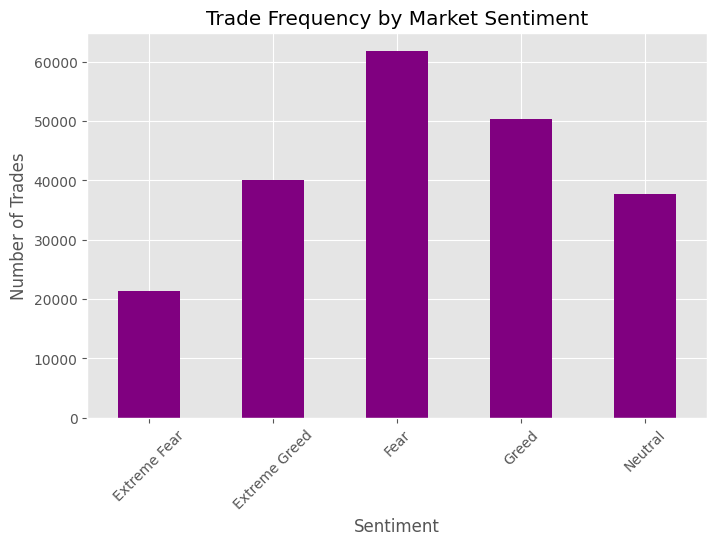

In [31]:
plt.figure(figsize=(8,5))

trade_frequency.plot(
    kind="bar",
    color="purple"
)

plt.title("Trade Frequency by Market Sentiment")

plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [32]:
trade_size = (
    merged.groupby("Sentiment")["Size USD"]
    .mean()
)

print(trade_size)

Sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


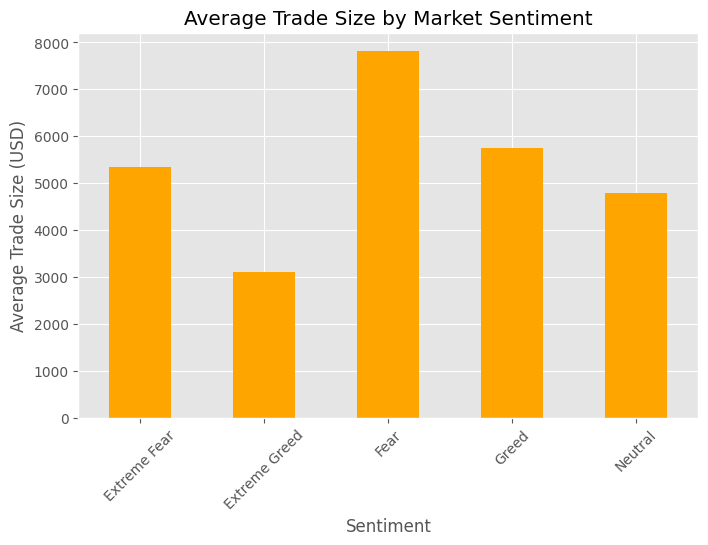

In [33]:
plt.figure(figsize=(8,5))

trade_size.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Trade Size by Market Sentiment")

plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

In [34]:
direction_sentiment = pd.crosstab(
    merged["Sentiment"],
    merged["Direction_Group"]
)

print(direction_sentiment)

Direction_Group  Buy/Sell   Long  Other  Short
Sentiment                                     
Extreme Fear         1849  13246     14   6291
Extreme Greed       12296  13486     50  14160
Fear                 6571  35084     74  20108
Greed               10671  16542    104  22986
Neutral              5231  20215     37  12203


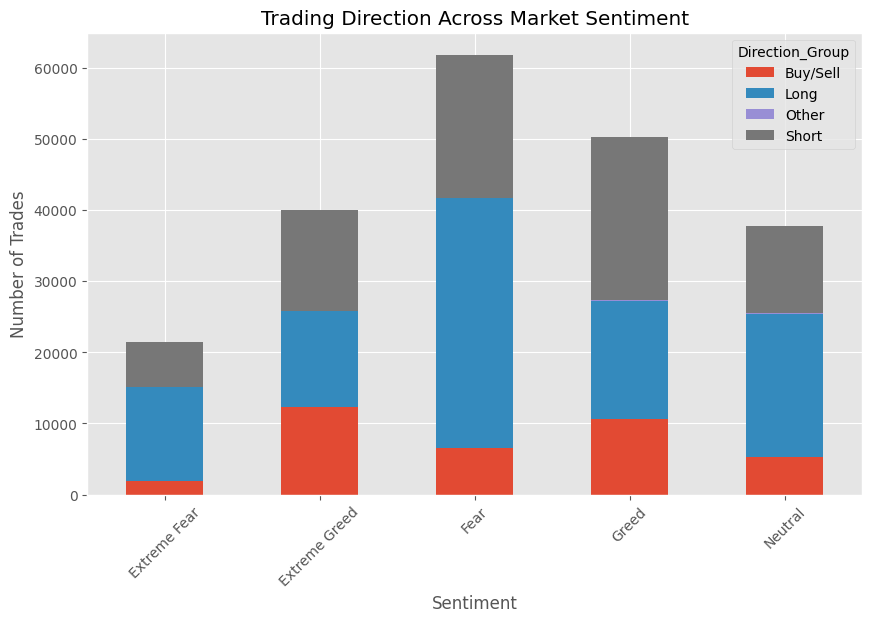

In [35]:
direction_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Trading Direction Across Market Sentiment")

plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [36]:
trade_count = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Total_Trades")
)

trade_count["Trader_Type"] = pd.qcut(
    trade_count["Total_Trades"],
    q=3,
    labels=[
        "Infrequent",
        "Moderate",
        "Frequent"
    ]
)

trade_count.head()

,Account,Total_Trades,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Moderate
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Moderate
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Moderate


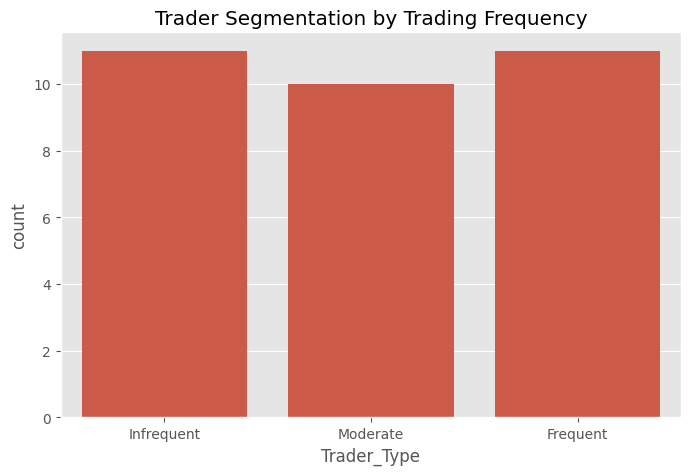

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trade_count,
    x="Trader_Type"
)

plt.title("Trader Segmentation by Trading Frequency")

plt.show()

In [38]:
profit_segment = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .reset_index()
)

profit_segment["Profitability"] = np.where(
    profit_segment["Closed PnL"] > 0,
    "Profitable",
    "Loss Making"
)

profit_segment.head()

,Account,Closed PnL,Profitability
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Profitable
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Loss Making
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Profitable
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Profitable


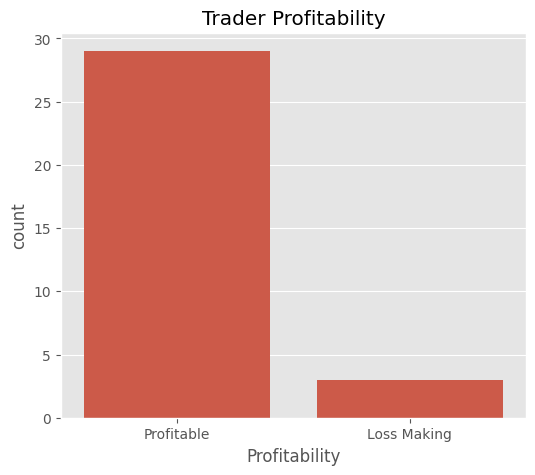

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=profit_segment,
    x="Profitability"
)

plt.title("Trader Profitability")

plt.show()

In [40]:
segment_analysis = trade_count.merge(
    profit_segment,
    on="Account"
)

segment_analysis.head()

,Account,Total_Trades,Trader_Type,Closed PnL,Profitability
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Moderate,1.600230e+06,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent,4.788532e+04,Profitable
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Moderate,-7.043619e+04,Loss Making
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent,1.324648e+05,Profitable
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Moderate,1.686580e+05,Profitable


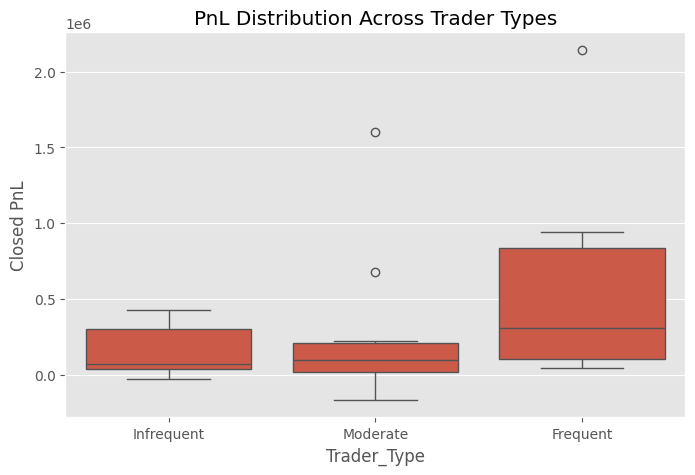

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=segment_analysis,
    x="Trader_Type",
    y="Closed PnL"
)

plt.title("PnL Distribution Across Trader Types")

plt.show()

In [42]:
summary = merged.groupby("Sentiment").agg(
    Average_PnL=("Closed PnL","mean"),
    Median_PnL=("Closed PnL","median"),
    Total_Trades=("Account","count"),
    Average_Trade_Size=("Size USD","mean")
).round(2)

summary

,Average_PnL,Median_PnL,Total_Trades,Average_Trade_Size
Sentiment,,,,
Extreme Fear,34.54,0.0,21400,5349.73
Extreme Greed,67.89,0.0,39992,3112.25
Fear,54.29,0.0,61837,7816.11
Greed,42.74,0.0,50303,5736.88
Neutral,34.31,0.0,37686,4782.73


In [43]:
top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

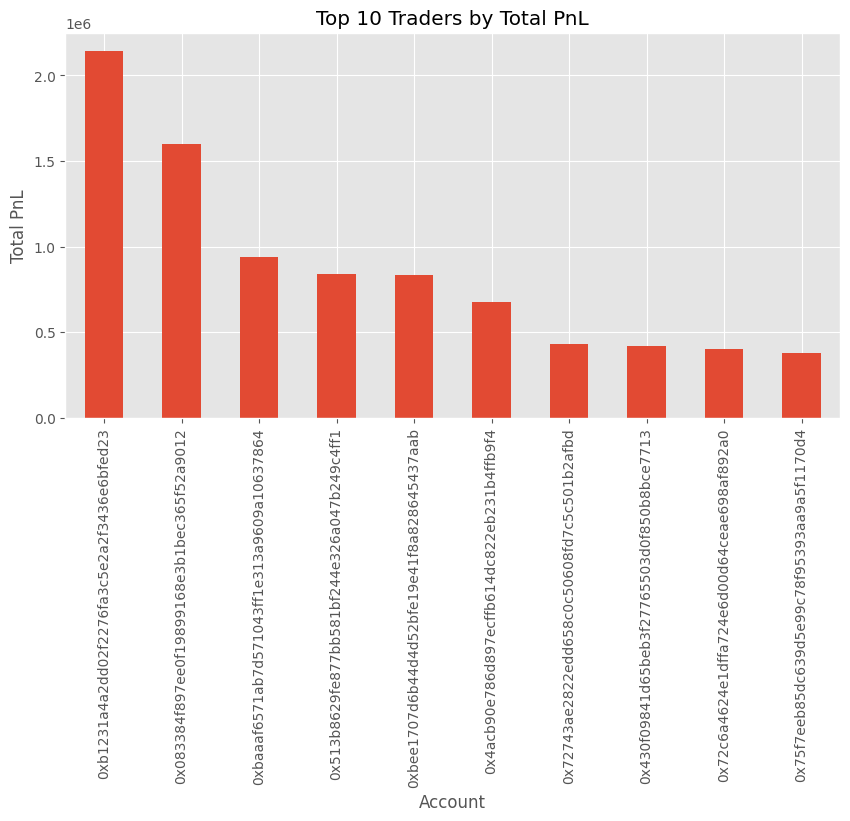

In [44]:
plt.figure(figsize=(10,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total PnL")

plt.ylabel("Total PnL")

plt.show()

In [45]:
bottom_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_traders

Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
Name: Closed PnL, dtype: float64

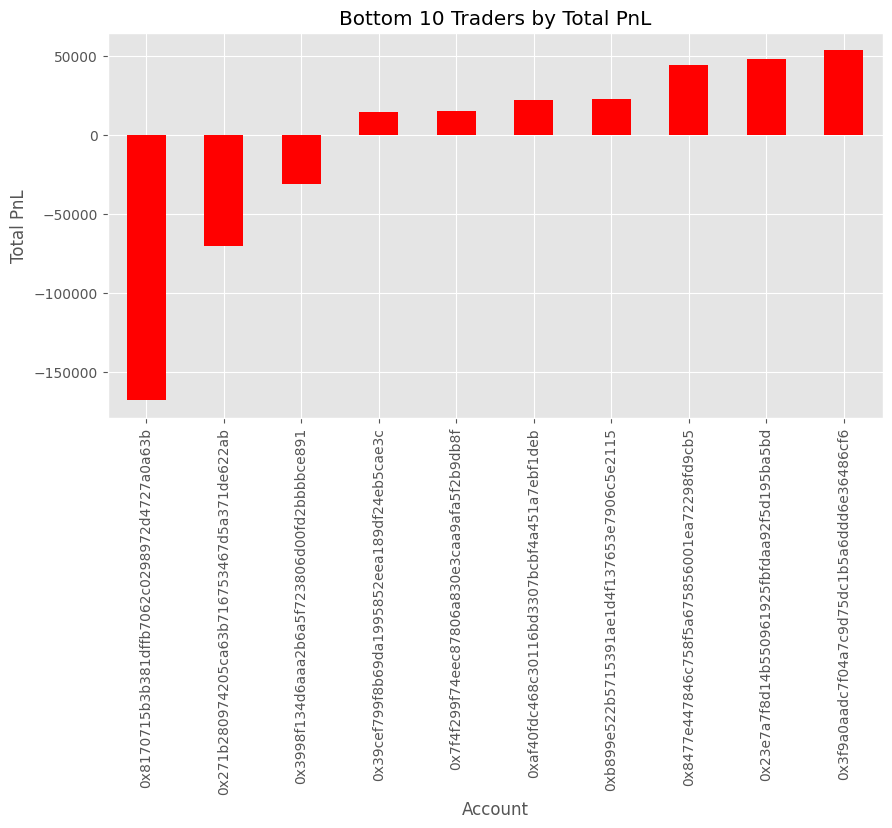

In [46]:
plt.figure(figsize=(10,5))

bottom_traders.plot(kind="bar", color="red")

plt.title("Bottom 10 Traders by Total PnL")

plt.ylabel("Total PnL")

plt.show()

In [47]:
win_rate_sentiment

Sentiment
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Trade_Result, dtype: float64

In [48]:
trade_frequency

Sentiment
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

# Insight 1: Traders Achieved Their Highest Win Rate During Extreme Greed

Observation
The highest trader win rate (46.49%) occurred during Extreme Greed, while Extreme Fear recorded the lowest win rate (37.06%).

Evidence
Chart: Win Rate by Market Sentiment
Table: Win Rate by Sentiment

Business Interpretation 
This suggests that traders were more successful in highly optimistic market conditions. Strong bullish momentum during Extreme Greed may have created more profitable trading opportunities, whereas heightened uncertainty during Extreme Fear likely reduced the probability of successful trades.

# Insight 2: Trading Activity Was Highest During Fear Markets

Observation
The highest number of trades (61,837 trades) occurred during Fear periods, followed by Greed (50,303 trades). In contrast, Extreme Fear recorded the lowest trading activity (21,400 trades).

Evidence
Chart: Trade Frequency by Market Sentiment
Table: Trade Frequency by Sentiment

Business Interpretation
This suggests that traders become more active during Fear markets, possibly because increased price volatility creates more short-term trading opportunities. However, despite the higher trading activity during Fear, the highest win rate occurred during Extreme Greed (46.49%), indicating that trading more frequently does not necessarily lead to better trading outcomes.

# Insight 3: Traders Allocated More Capital During Fear Markets

Observation
The highest average trade size occurred during Fear ($7,816.11), followed by Greed ($5,736.88). In contrast, Extreme Greed had the smallest average trade size ($3,112.25).

Evidence
Chart: Average Trade Size by Market Sentiment
Table: Average Trade Size by Sentiment

Business Interpretation
Although traders placed more trades during Fear periods and also committed the largest average capital per trade, this did not produce the highest win rate. In contrast, Extreme Greed achieved the highest win rate despite having the smallest average trade size. This suggests that market conditions and trade quality may have a greater impact on profitability than simply increasing trading volume or capital allocation.

# Strategy Recommendations based on the findings 

# Recommendation 1: Use Market Sentiment as a Risk Management Signal

The analysis showed that Extreme Greed achieved the highest win rate (46.49%), whereas Extreme Fear had the lowest win rate (37.06%). This indicates that traders were considerably more successful during optimistic market conditions.

Action:
Incorporate the Fear & Greed Index into the trading decision process.
During Extreme Fear, reduce risk exposure by trading smaller positions or waiting for stronger trade confirmations.
During Extreme Greed, continue trading but maintain disciplined risk management instead of increasing exposure solely because market sentiment is positive.

# Recommendation 2: Prioritize Trade Quality Instead of Trade Quantity

The analysis found that Fear recorded the highest trading activity (61,837 trades), yet it did not achieve the highest win rate. This suggests that increasing the number of trades does not necessarily improve profitability.

Action:
Avoid overtrading during highly volatile market conditions.
Enter trades only when supported by strong technical or quantitative signals.
Focus on executing fewer, higher-quality trades instead of reacting to every market movement.